In [ ]:
import pickle


def load_df(path):
    with open(path, "rb") as f:
        return pickle.load(f).get_dataframe()

def format_path(path):
    exports_folder_path = "/private/schwartz-lab/yarin_shaked7/SkyRL/data/exports/"
    file_path = "eval_summary_table.pkl"
    return exports_folder_path + path + file_path

complexity_based_path = "RTX6000_r_SPARTAN_i_VANILLA_model_Qwen/Qwen3-4B_spartan_rl_reward_cyclomatic_complexity_spartan_reward_coef_10.0_format_reward_coef_0.5_accuracy_reward_coef_1.0_context_4000_lr_1.0e-5/"
variable_based_path = "RTX6000_r_SPARTAN_i_VANILLA_model_Qwen/Qwen3-4B_spartan_rl_reward_unique_variable_count_spartan_reward_coef_10.0_format_reward_coef_0.5_accuracy_reward_coef_1.0_context_4000_lr_1.0e-5/"
volume_based_path = "RTX6000_rewards_SPARTAN_instructions_VANILLA_model_Qwen/Qwen3-4B_spartan_reward_coef_10.0_format_reward_coef_0.5_accuracy_reward_coef_1.0_context_4000_lr_1.0e-5/"


r_vanilla_i_vanilla = "RTX6000_rewards_VANILLA_instructions_VANILLA_model_Qwen/Qwen3-4B_spartan_reward_coef_10.0_format_reward_coef_0.5_accuracy_reward_coef_1.0_context_4000_lr_1.0e-5/"
r_spartan_i_spartan = "L40_rewards_SPARTAN_instructions_SPARTAN_model_Qwen/Qwen3-4B_spartan_reward_coef_10.0_format_reward_coef_0.5_accuracy_reward_coef_1.0_context_4000_lr_1.0e-5/"
r_vanilla_i_spartan = "RTX6000_rewards_VANILLA_instructions_SPARTAN_model_Qwen/Qwen3-4B_spartan_reward_coef_10.0_format_reward_coef_0.5_accuracy_reward_coef_1.0_context_4000_lr_1.0e-5/"
r_spartan_i_vanilla = "RTX6000_rewards_SPARTAN_instructions_VANILLA_model_Qwen/Qwen3-4B_spartan_reward_coef_10.0_format_reward_coef_0.5_accuracy_reward_coef_1.0_context_4000_lr_1.0e-5/"

comparison_type = "spartan"


if comparison_type == "spartan":
    input_dataframes = {
        'Complexity-based': load_df(format_path(complexity_based_path)),
        'Variable-based': load_df(format_path(variable_based_path)),
        'Volume-based': load_df(format_path(volume_based_path)),
        'r_vanilla_i_vanilla': load_df(format_path(r_vanilla_i_vanilla)),
        'r_spartan_i_spartan': load_df(format_path(r_spartan_i_spartan)),
        'r_vanilla_i_spartan': load_df(format_path(r_vanilla_i_spartan)),
    }
else:
    input_dataframes = {
        'r_vanilla_i_vanilla': load_df(format_path(r_vanilla_i_vanilla)),
        'r_spartan_i_spartan': load_df(format_path(r_spartan_i_spartan)),
        'r_vanilla_i_spartan': load_df(format_path(r_vanilla_i_spartan)),
        'r_spartan_i_vanilla': load_df(format_path(r_spartan_i_vanilla)),
    }

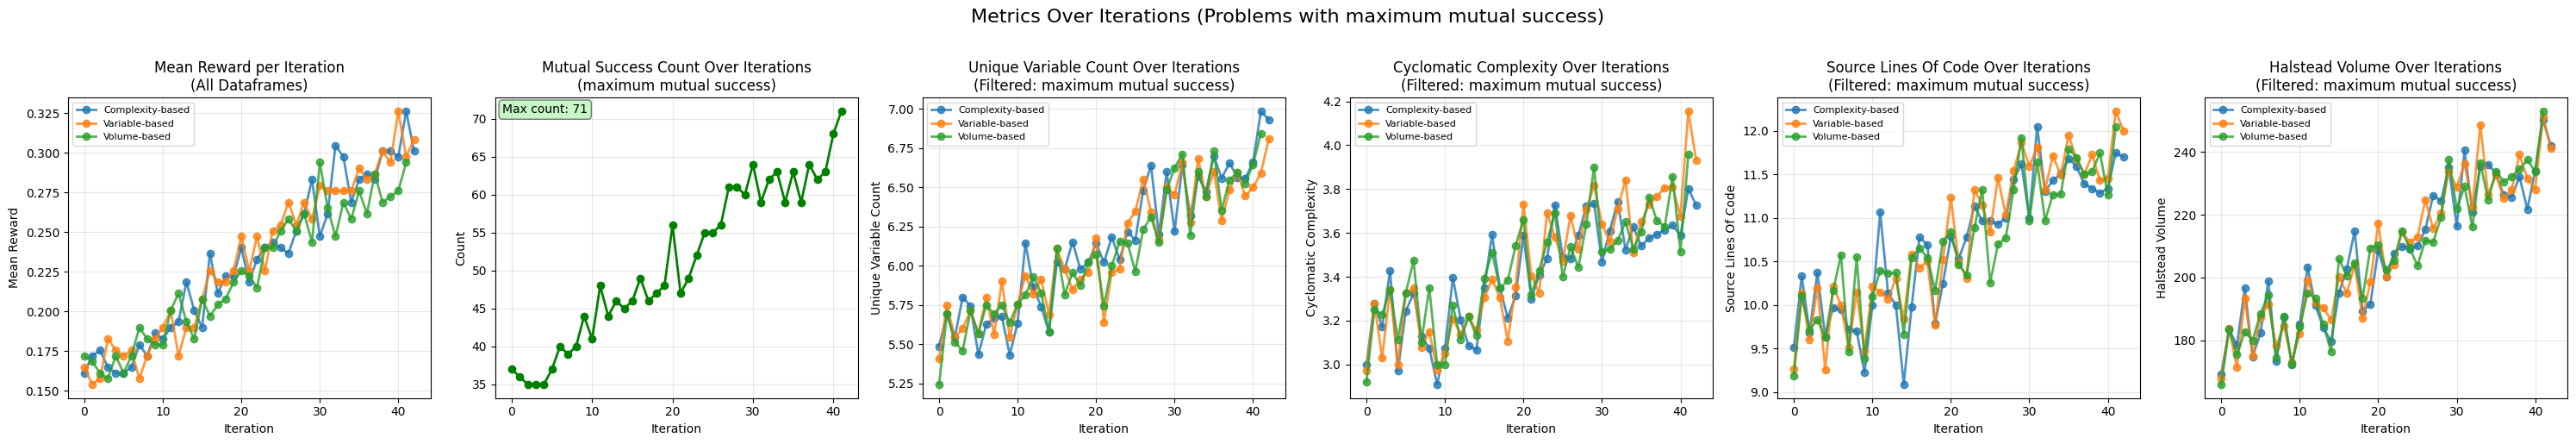

In [9]:
import numpy as np
import matplotlib.pyplot as plt

dataset_size = 279

# Metrics to plot (excluding reward - we'll plot count instead)
metrics = [
    ("unique_variable_count", "Unique Variable Count"),
    ("cyclomatic_complexity", "Cyclomatic Complexity"),
    ("source_lines_of_code", "Source Lines Of Code"),
    ("halstead_volume", "Halstead Volume")
]

# Use input_dataframes directly
dataframe_labels = list(input_dataframes.keys())
dataframes_list = list(input_dataframes.values())
num_dataframes = len(input_dataframes)

# Calculate number of iterations for each dataframe separately
num_iterations_per_df = {
    label: len(df) // dataset_size
    for label, df in input_dataframes.items()
}

if num_iterations_per_df:
    max_iterations = max(num_iterations_per_df.values())
    min_iterations = min(num_iterations_per_df.values())
else:
    max_iterations = 0
    min_iterations = 0

# Store results for each dataframe and metric
iteration_results = {
    label: {metric[0]: [] for metric in metrics}
    for label in dataframe_labels
}
mutual_success_count = []  # Store count of problems with maximum mutual success
mean_reward = {label: [] for label in dataframe_labels}  # Store mean reward per iteration

# Process mean reward for each dataframe independently (all iterations)
for label, df in input_dataframes.items():
    num_iterations = num_iterations_per_df[label]
    for iteration in range(num_iterations):
        start_idx = iteration * dataset_size
        end_idx = (iteration + 1) * dataset_size
        iter_data = df.iloc[start_idx:end_idx]
        mean_reward[label].append(iter_data['reward'].mean())

# Process mutual success and metrics for common iterations (up to minimum iterations)
for iteration in range(min_iterations):
    start_idx = iteration * dataset_size
    end_idx = (iteration + 1) * dataset_size
    
    # Extract data for this iteration from all dataframes
    iter_dataframes = [df.iloc[start_idx:end_idx] for df in dataframes_list]
    
    # Calculate mutual success: find maximum number of dataframes with reward=1
    # For each problem, count how many dataframes have reward=1
    reward_matrix = np.array([
        (df['reward'] == 1).values for df in iter_dataframes
    ])
    
    num_successes_per_problem = reward_matrix.sum(axis=0)
    
    # Find the maximum number of successes across all problems
    max_successes = num_successes_per_problem.max()
    
    # Count problems with the maximum number of successes
    if max_successes > 0:
        count = (num_successes_per_problem == max_successes).sum()
    else:
        count = 0
    
    mutual_success_count.append(count)
    
    # Create mask for problems with maximum mutual success
    mask = num_successes_per_problem == max_successes
    
    # Calculate metrics for filtered problems from each dataframe
    for i, label in enumerate(dataframe_labels):
        filtered_df = iter_dataframes[i][mask]
        for metric_name, _ in metrics:
            if len(filtered_df) > 0:
                metric_values = filtered_df[metric_name].dropna()
                if len(metric_values) > 0:
                    iteration_results[label][metric_name].append(metric_values.mean())
                else:
                    iteration_results[label][metric_name].append(np.nan)
            else:
                iteration_results[label][metric_name].append(np.nan)

# Process metrics for remaining iterations of each dataframe
# Now we filter based on problems that **all of the remaining dataframes** succeeded on
for iteration in range(min_iterations, max_iterations):
    # Dataframes that still have this iteration ("remaining dataframes")
    active_labels = [
        label for label, n_iter in num_iterations_per_df.items()
        if n_iter > iteration
    ]

    if not active_labels:
        continue

    # Build reward matrix for active dataframes at this iteration
    iter_data_by_label = {}
    reward_rows = []
    for label in active_labels:
        df = input_dataframes[label]
        start_idx = iteration * dataset_size
        end_idx = (iteration + 1) * dataset_size
        iter_df = df.iloc[start_idx:end_idx]
        iter_data_by_label[label] = iter_df
        reward_rows.append((iter_df['reward'] == 1).values)

    reward_matrix_remaining = np.array(reward_rows)

    # Problems that all remaining dataframes succeeded on
    all_success_mask = reward_matrix_remaining.all(axis=0)

    # If no problem was solved by all remaining dataframes, append NaNs
    if not all_success_mask.any():
        for label in active_labels:
            for metric_name, _ in metrics:
                iteration_results[label][metric_name].append(np.nan)
        continue

    # Compute metrics for each active dataframe on the filtered problems
    for label in active_labels:
        filtered_df = iter_data_by_label[label][all_success_mask]
        for metric_name, _ in metrics:
            metric_values = filtered_df[metric_name].dropna()
            if len(metric_values) > 0:
                iteration_results[label][metric_name].append(metric_values.mean())
            else:
                iteration_results[label][metric_name].append(np.nan)

# Create subplots (6 subplots: mean reward + mutual success + 4 metrics)
fig, axs = plt.subplots(1, 6, figsize=(30, 5))

# Generate colors dynamically
# Using tab10 colormap, or similar if more than 10 lines needed
colors = plt.cm.tab10(np.linspace(0, 1, max(10, num_dataframes)))

# Plot mean reward for each dataframe (first subplot) - all iterations for each dataframe
for idx, label in enumerate(dataframe_labels):
    num_iterations = num_iterations_per_df[label]
    axs[0].plot(range(num_iterations), mean_reward[label], marker='o', linewidth=2,
                label=label, color=colors[idx], alpha=0.8)
axs[0].set_xlabel('Iteration')
axs[0].set_ylabel('Mean Reward')
axs[0].set_title('Mean Reward per Iteration\n(All Dataframes)')
axs[0].grid(True, alpha=0.3)
axs[0].legend(loc='best', fontsize=8)

# Plot count of mutual successes (second subplot)
axs[1].plot(range(min_iterations), mutual_success_count, marker='o', linewidth=2, color='green')
axs[1].set_xlabel('Iteration')
axs[1].set_ylabel('Count')
axs[1].set_title('Mutual Success Count Over Iterations\n(maximum mutual success)')
axs[1].grid(True, alpha=0.3)
if len(mutual_success_count) > 0:
    axs[1].text(0.02, 0.98, f'Max count: {max(mutual_success_count)}', 
                transform=axs[1].transAxes, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))

# Plot each metric (remaining 4 subplots) - one line per dataframe, all iterations
for idx, (metric_name, metric_label) in enumerate(metrics):
    ax_idx = idx + 2  # Start from index 2 (0 is mean reward, 1 is mutual success)
    
    # Plot a line for each dataframe - all iterations
    for df_idx, label in enumerate(dataframe_labels):
        values = iteration_results[label][metric_name]
        num_iterations = num_iterations_per_df[label]
        axs[ax_idx].plot(range(num_iterations), values, marker='o', linewidth=2, 
                        label=label, color=colors[df_idx], alpha=0.8)
    
    axs[ax_idx].set_xlabel('Iteration')
    axs[ax_idx].set_ylabel(metric_label)
    axs[ax_idx].set_title(f'{metric_label} Over Iterations\n(Filtered: maximum mutual success)')
    axs[ax_idx].grid(True, alpha=0.3)
    axs[ax_idx].legend(loc='best', fontsize=8)

plt.suptitle('Metrics Over Iterations (Problems with maximum mutual success)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()
